# momapy-kb: a python library to integrate maps in neo4j

momapy-kb is a python library to integrate maps into Neo4j. It relies on two other libraries:
* momapy, a library for working with maps
* fieldz-kb, a library for integrating dataclass-like python objects into Neo4j

## Fieldz-kb

In [1]:
import dataclasses
import fieldz_kb.neo4j.core
import neo4j
import credentials

### Storing objects to Neo4j automatically

We make a simple object class:

In [2]:
@dataclasses.dataclass
class A:
    w: int | None = None # optional
    x: list[str] = dataclasses.field(default_factory=list)

In [3]:
a = A(1, ["a", "b", "c", "d"])

We connect to the database, and remove all its content:

In [4]:
fieldz_kb.neo4j.core.connect(credentials.HOST_NAME, credentials.USER_NAME, credentials.PASSWORD, notifications_min_severity="off") # connection
fieldz_kb.neo4j.core.delete_all()

We save the object we made to the database:

In [5]:
fieldz_kb.neo4j.core.save_from_object(a)

We can make complex objects, i.e., objects that contain other self-defined objects, and save them to the database using the same function:

In [6]:
@dataclasses.dataclass
class B:
    y: float
    z: list[A] = dataclasses.field(default_factory=list)

In [7]:
a1 = A(1, ["a1_1", "a1_2"])
a2 = A(2, ["a2_1", "a2_2"])
b = B(1.0, [a1, a2])

In [8]:
fieldz_kb.neo4j.core.save_from_object(b)

### Integration modes

We can integrate objects, based on their id or their hash.

By default, objects are not integrated, i.e., objects that are the same are modeled using different nodes:

In [9]:
b = B(1.0, [a1, a1])
fieldz_kb.neo4j.core.delete_all()
fieldz_kb.neo4j.core.save_from_object(b)
query = "MATCH (n:A) RETURN n"
results, meta = fieldz_kb.neo4j.core.cypher_query(query, resolve_objects=True)

In [10]:
assert len(results) == 2

With the integration mode enabled, objects that are the same (based on their id or their hash) are modeled using the same node:

In [11]:
fieldz_kb.neo4j.core.delete_all()
fieldz_kb.neo4j.core.save_from_object(b, integration_mode="id")
query = "MATCH (n:A) RETURN n"
results, meta = fieldz_kb.neo4j.core.cypher_query(query, resolve_objects=True)
assert len(results) == 1

### Re-building objects from nodes

We can query a node, and transform it back to a python object:

In [12]:
query = "MATCH (n:B) RETURN n LIMIT 1"
results, meta = fieldz_kb.neo4j.core.cypher_query(query, resolve_objects=True)
for row in results:
    node = row[0]
    obj = fieldz_kb.neo4j.core.make_object_from_node(node)
    break

The object we obtain is the same as the one we stored in the database:

In [13]:
assert obj == b

## Momapy-kb

momapy-kb is based on fieldz-kb and momapy; it just offers convenience functions built around the two packages, to apply fieldz-kb capabilities to momapy maps.

In [14]:
import momapy_kb.neo4j.core
from utils import display

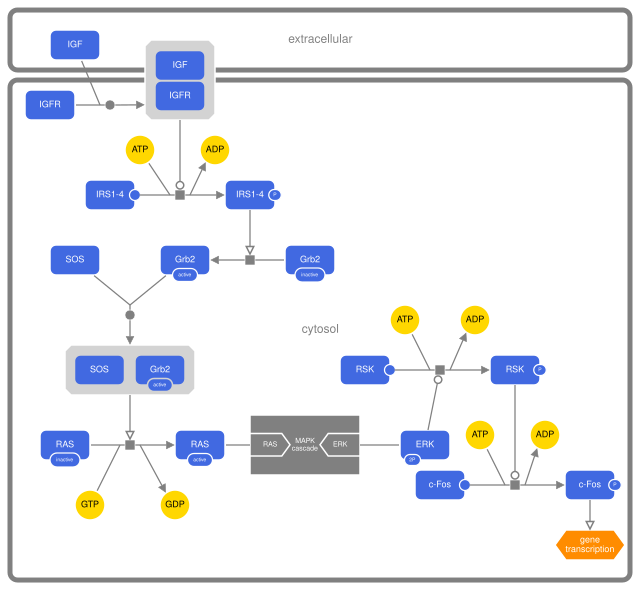

In [15]:
display("insulin.sbgn", scale=0.5, style_sheet="mk.css")

### Functions from fieldz-kb

* connect
* delete_all
* save_from_object
* make_nodes_from_object
* make_object_from_node

### Read and save momapy objects directly from a file

We can save a map directly from a file:

In [16]:
momapy_kb.neo4j.core.delete_all()
momapy_kb.neo4j.core.save_from_file("insulin.sbgn", integration_mode="hash")

We can also save only the model (resp. layout), using the `return_type` option:

In [17]:
momapy_kb.neo4j.core.delete_all()
momapy_kb.neo4j.core.save_from_file("insulin.sbgn", return_type="model", integration_mode="hash")

### Querying

#### Using the OGM

For simple queries, the OGM can be used:

In [18]:
import momapy_kb.neo4j.sbgn.pd

In [19]:
macromolecule_nodes = momapy_kb.neo4j.sbgn.pd.Macromolecule.nodes.all()

In [20]:
print(len(macromolecule_nodes))

14


In [21]:
c_fos_nodes = momapy_kb.neo4j.sbgn.pd.Macromolecule.nodes.filter(label__exact="c-Fos")
print(len(c_fos_nodes))

2


#### Using Cypher

Simple and more complex queries can be expressed using Cypher.

We query all macromolecules:

In [22]:
query = "MATCH (n:Macromolecule) RETURN n"
results, meta = momapy_kb.neo4j.core.cypher_query(query)
assert len(results) == 14

We query all phosphorylation processes:

In [23]:
query = """
    MATCH (p:GenericProcess),
    (p)-[:HAS_REACTANT]->()-[:HAS_ELEMENT]->(reactant)-[:HAS_STATE_VARIABLE]->(reactant_sv),
    (p)-[:HAS_PRODUCT]->()-[:HAS_ELEMENT]->(product)-[:HAS_STATE_VARIABLE]->(product_sv)
    WHERE reactant.label = product.label
    AND reactant_sv.value IS NULL AND product_sv.value = "P"
    AND (reactant_sv.variable IS NULL AND product_sv.variable IS NULL and reactant_sv.order = product_sv.order
    OR reactant_sv.variable = product_sv.variable)
    RETURN p
"""
results, meta = momapy_kb.neo4j.core.cypher_query(query)
print(len(results))

3


### Render query results as map excerpts

We store the whole map to Neo4j:

In [24]:
momapy_kb.neo4j.core.delete_all()
momapy_kb.neo4j.core.save_from_file("insulin.sbgn", integration_mode="hash")

In [25]:
query = "MATCH (n:Macromolecule) RETURN n"
results, _ = momapy_kb.neo4j.core.cypher_query(query, resolve_objects=True)

For each macromolecule node in the result of our query, we fetch the corresponding layout element nodes in the database, and transform them to layout element objects that can be rendered:

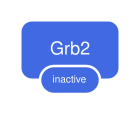

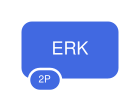

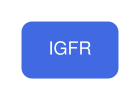

In [26]:
for row in results[:3]:
    macromolecule_node = row[0]
    layout_element = momapy_kb.neo4j.core.make_layout_elements_from_model_element_node(macromolecule_node)[0]
    display(layout_element, style_sheet="mk.css")

We do the same for phosphorylation processes, this time directly obtaining the layout element objects from the query, with no intermediate result:

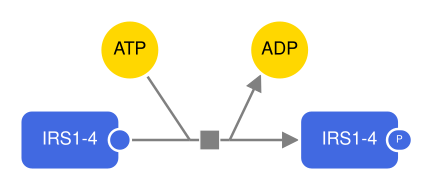

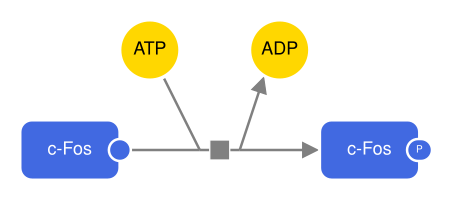

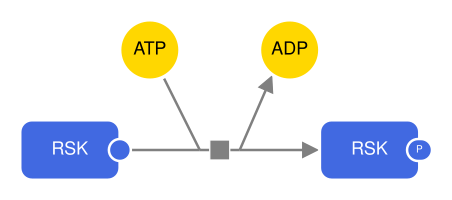

In [27]:
query = """
    MATCH (p:GenericProcess),
    (p)-[:HAS_REACTANT]->()-[:HAS_ELEMENT]->(reactant)-[:HAS_STATE_VARIABLE]->(reactant_sv),
    (p)-[:HAS_PRODUCT]->()-[:HAS_ELEMENT]->(product)-[:HAS_STATE_VARIABLE]->(product_sv)
    WHERE reactant.label = product.label
    AND reactant_sv.value IS NULL AND product_sv.value = "P"
    AND (reactant_sv.variable IS NULL AND product_sv.variable IS NULL and reactant_sv.order = product_sv.order
    OR reactant_sv.variable = product_sv.variable)
    RETURN p
"""
layout_element_results = momapy_kb.neo4j.core.make_layout_element_results_from_cypher_query(query)
for row in layout_element_results:
        display(row, style_sheet="mk.css")

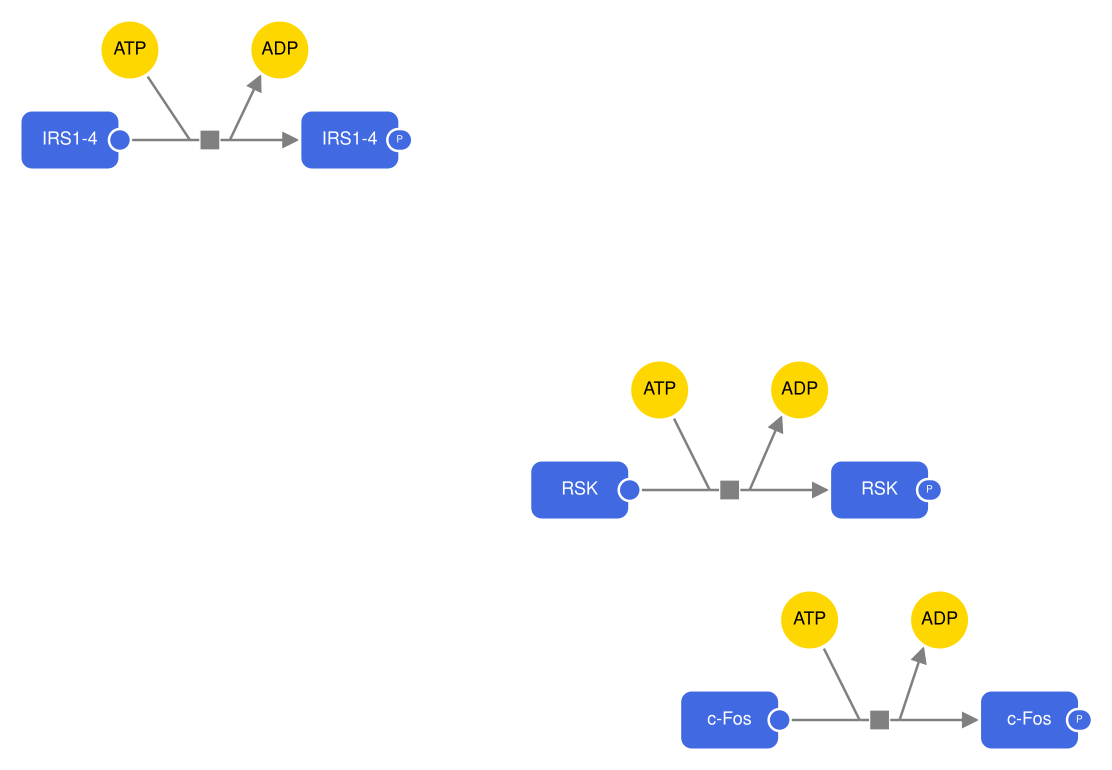

In [28]:
layout_elements = sum(layout_element_results, [])
display(layout_elements, style_sheet="mk.css")

## Future work

* Additonal backends:
    - Kuzu: Cypher, serverless, faster than Neo4j (but only one label per Node)
    - Answer Set Programming: for complex problems, reasoning, transformation (e.g., PD to AF)
    - RDF?
* Webapp based on momapy-kb (Neo4j) to integrate and query maps:
    - Store/integrate/query maps (some functions already in neo4j-dm to create integrated collections of maps)
    - Visualize results: as graphs/text (same as Neo4j-browser); as excerpts of maps
* New tool for natural language querying (Neo4j)
    - Based on LLMs(+SBGN bricks)
    - Integrated to the Webapp